# 03 · Report — the walk's score on train, validation and test, by category and for every card

## Executive summary (read this first)

The model is the **cumulative random walk with Cholesky**, with the **one-per-family** settings chosen in
notebook 02 (`window` = steps the sd and correlation are measured on, `widen` = multiplier on the width).
This notebook backtests it on **every card** and reports its score on each of the three blocks of dates:

| block | what it was used for in notebook 02 | how to read its score here |
|---|---|---|
| **train** | choosing each family's `window` and `widen` | optimistic: the settings were picked to do well here |
| **validation** | choosing "one per family" over the other ways | slightly optimistic: the way was picked here |
| **test** | nothing: opened once | the honest estimate of how the model does on new dates |

Every score is the **card's own score** from its `card.toml` (0.5 × CRPS + 0.3 × variogram + 0.2 × tail;
lower is better), raw (no M0), with its three parts and the **share of answers inside the forecast's 50 % and
90 % bands** (a calibrated forecast: 50 % and 90 %).

A raw score is in the card's own units (a payrolls card scores in the hundreds, a yield card below 1), so a
category's **mean** is pulled up by its big-unit cards; its **median** is shown next to it. The band shares
have no units and compare directly across cards and categories.

Reads `data/targets.parquet`, `data/steps.parquet` (notebook 01) and `data/walk_settings.csv` (notebook 02).
No realized outcome is read: the answers are later rows of each card's own history.

## 0 — Setup, data and the model's settings

In [1]:
import json, multiprocessing as mp, pathlib, subprocess, sys, tempfile, time, tomllib
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd() if pathlib.Path.cwd().name == "model_baseline" else pathlib.Path.cwd() / "model_baseline"
REPO, DATA, UNITS = HERE.parent, HERE / "data", HERE.parent / "units"
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 150)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
FAM = {"T2-F1": "#2a78d6", "T2-F2": "#eb6834", "T2-F3": "#1baf7a", "T2-F4": "#4a3aa7"}
BLOCK = {"train": "#2a78d6", "validation": "#1baf7a", "test": "#eb6834"}
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": GRID, "axes.edgecolor": INK2,
                     "axes.titlelocation": "left", "legend.frameon": False, "font.size": 10})

TARGETS = pd.read_parquet(DATA / "targets.parquet")
STEPS = pd.read_parquet(DATA / "steps.parquet")
CARDS = {u: tomllib.loads((UNITS / u / "card.toml").read_text()) for u in sorted(TARGETS.unit.unique())}
WORKERS = max(1, (mp.cpu_count() or 2) - 2)
geo = lambda r: float(np.exp(np.log(np.asarray(r, float)).mean()))

def parse(setting):                      # "130 / 1.1" -> {"window": 130, "widen": 1.1}
    w, wd = (x.strip() for x in str(setting).split("/"))
    return {"window": int(w), "widen": float(wd)}

chosen = pd.read_csv(DATA / "walk_settings.csv", index_col=0)["one per family"]
MODEL = {u: parse(chosen[u]) for u in CARDS}                                   # the model: one setting per family
PRODUCTION = {"window": 260, "widen": 1.0}                                     # production's settings (for the code check only)
fam_settings = (pd.DataFrame({u: {"family": CARDS[u]["metadata"]["category"], **MODEL[u]} for u in CARDS}).T
                  .drop_duplicates().set_index("family").sort_index())
print(f"{len(CARDS)} cards. The model's settings (chosen in notebook 02, one per family):")
fam_settings

103 cards. The model's settings (chosen in notebook 02, one per family):


,window,widen
family,,
T2-F1,42,1.1
T2-F2,130,1.0
T2-F3,130,1.0
T2-F4,260,1.1


## 1 — The model and the score

The same two functions as notebook 02 (repeated here: these notebooks do not share code files).
`walk_forecast` is the cumulative random walk with Cholesky; `card_score` is the card's own score through the
official composite function.

In [2]:
MIN_CHANGES = 10

def walk_forecast(steps, origin, anchor, ksteps, horizons, window=260, widen=1.0, n_draws=1000, seed=0):
    """Cumulative random walk with Cholesky, fitted on the `window` steps up to the origin. -> (n_draws, n_assets, n_horizons)"""
    i = steps.index.searchsorted(pd.Timestamp(origin), side="right")
    past = steps.to_numpy()[max(0, i - window): i]
    if len(past) < MIN_CHANGES:
        raise ValueError(f"only {len(past)} steps before {origin} (window {window})")
    n_a = past.shape[1]
    D = np.ascontiguousarray(past.T)
    sd = D.std(axis=1) * widen
    with np.errstate(invalid="ignore", divide="ignore"):
        corr = np.nan_to_num(np.atleast_2d(np.corrcoef(D)), nan=0.0)
    np.fill_diagonal(corr, 1.0)
    w, v = np.linalg.eigh(corr)
    corr = v @ np.diag(np.clip(w, 1e-8, None)) @ v.T
    L = np.linalg.cholesky(corr)
    rng = np.random.default_rng(seed)
    out = np.empty((n_draws, n_a, len(horizons)))
    path, prev = np.zeros((n_draws, n_a)), np.zeros(n_a)
    for hi in np.argsort(horizons):
        z = rng.standard_normal((n_draws, n_a)) @ L.T
        rng.standard_normal((n_draws, n_a))                                    # production's skew draw (unused)
        kk = np.asarray(ksteps, float)[:, hi]
        path = path + z * sd * np.sqrt(np.maximum(kk - prev, 0))
        prev = kk
        out[:, :, hi] = np.asarray(anchor, float) + path
    return out

from qfbench2_track_forecasting import scoring as S

def card_score(card, samples, y):
    """The card's own score (raw), plus the share of cells inside the 50% and 90% bands."""
    p = card.get("scoring", {}).get("params", {})
    w = p.get("weights", {"marginal": 0.5, "joint": 0.3, "tail": 0.2})
    w = (float(w["marginal"]), float(w["joint"]), float(w["tail"]))
    if samples.shape[1] == 1:
        live = w[0] + w[2]; w = (w[0] / live, 0.0, w[2] / live)
    out = S._composite(samples, y, weights=w, tail_levels=tuple(p.get("tail_levels", (0.01, 0.05, 0.95, 0.99))),
                       joint=S.card_joint_statistic(card), tail_metric=str(p.get("tail_metric", S.DEFAULT_TAIL_METRIC)),
                       ref_scale=None)
    q = np.quantile(samples, [0.05, 0.25, 0.75, 0.95], axis=0)
    return {**out, "cov50": float(np.mean((y >= q[1]) & (y <= q[2]))), "cov90": float(np.mean((y >= q[0]) & (y <= q[3])))}

def card_inputs(u):
    card = CARDS[u]; t = card["targets"]
    assets, horizons = [str(a) for a in t["asset_ids"]], [int(h) for h in t["horizons"]]
    steps = STEPS[STEPS.unit == u].pivot(index="date", columns="asset", values="step")[assets].sort_index()
    tt = TARGETS[TARGETS.unit == u].set_index(["origin_date", "asset", "horizon"]).sort_index()
    return card, assets, horizons, steps, tt

def at_origin(tt, origin, assets, horizons):
    r = tt.loc[origin]
    anchor = np.array([r.loc[(a, horizons[0]), "anchor"] for a in assets])
    ksteps = np.array([[r.loc[(a, h), "steps"] for h in horizons] for a in assets])
    y = np.array([r.loc[(a, h), "target"] for a in assets for h in horizons])
    return anchor, ksteps, y

**Quick code checks** — at production's settings `walk_forecast` gives production's draws exactly, and `card_score` equals the official scorer's number.

In [3]:
import forecast_agent as fa, forecast_models as fm
u = "t2-F3-boj-ust-channel-2023"
card, assets, horizons, steps, tt = card_inputs(u); t = card["targets"]
o = np.sort(tt[tt.split == "test"].index.get_level_values(0).unique())[100]
anchor, ksteps, y = at_origin(tt, o, assets, horizons)
mine = walk_forecast(steps, o, anchor, ksteps, horizons, seed=3, **PRODUCTION)
req = fm._Request(fa._read_panels(UNITS / u), assets, horizons, str(pd.Timestamp(o).date()), {a: {} for a in assets},
                  1000, 3, t["target_type"], None)   # family None: production's plain walk (260 / 1.0 / normal)
print("walk_forecast vs production, max |difference|:", float(np.abs(mine - fm._cumulative_walk_model(req)).max()))

d3 = walk_forecast(steps, o, anchor, ksteps, horizons, **MODEL[u])
with tempfile.TemporaryDirectory() as tmp:
    out_dir, real = pathlib.Path(tmp) / "out", pathlib.Path(tmp) / "realized.parquet"; out_dir.mkdir()
    pd.DataFrame([{"draw": np.int32(d), "asset": a, "horizon": np.int32(h), "value": float(d3[d, ai, hi])}
                  for d in range(len(d3)) for ai, a in enumerate(assets) for hi, h in enumerate(horizons)]).to_parquet(out_dir / "forecast.parquet", index=False)
    (out_dir / "forecast_meta.json").write_text(json.dumps({"unit_id": card["task"]["id"], "asof": card["provenance"]["data_cutoff"],
        "representation": "samples", "asset_ids": assets, "horizons": horizons, "n_draws": len(d3), "target": t["target_type"]}))
    (out_dir / "forecast_rationale.md").write_text("# check\n")
    pd.DataFrame([{"asset": a, "horizon": h, "value": float(v)} for (a, h), v in zip([(a, h) for a in assets for h in horizons], y)]).to_parquet(real, index=False)
    r = subprocess.run([sys.executable, str(REPO / "scoring" / "scoring.py"), "score", "--card", str(UNITS / u / "card.toml"),
                        "--forecast", str(out_dir / "forecast.parquet"), "--realized", str(real)], capture_output=True, text=True, cwd=REPO)
official = json.loads(r.stdout)["composite_score"]; mine_score = card_score(card, d3.reshape(len(d3), -1), y)["composite"]
print(f"model score {mine_score:.10f}  official scorer {official:.10f}  equal: {np.isclose(mine_score, official, rtol=0, atol=1e-12)}")
assert float(np.abs(mine - fm._cumulative_walk_model(req)).max()) == 0 and np.isclose(mine_score, official, rtol=0, atol=1e-12)

walk_forecast vs production, max |difference|: 0.0


model score 2.8588896375  official scorer 2.8588896375  equal: True


## 2 — Backtest every card on train, validation and test

Every 5th date of each block, 1,000 draws, the model's per-family setting. Cards run in parallel.

In [4]:
STRIDE, N_DRAWS, BLOCKS = 5, 1000, ["train", "validation", "test"]

def backtest_card(u):
    card, assets, horizons, steps, tt = card_inputs(u)
    fam = card["metadata"]["category"]
    rows = []
    for block in BLOCKS:
        sub = tt[tt.split == block]
        for j, o in enumerate(np.sort(sub.index.get_level_values(0).unique())[::STRIDE]):
            anchor, ksteps, y = at_origin(sub, o, assets, horizons)
            try:
                d = walk_forecast(steps, o, anchor, ksteps, horizons, n_draws=N_DRAWS, seed=j, **MODEL[u])
            except ValueError:
                continue                                                       # too little history at this date
            rows.append({"unit": u, "family": fam, "block": block, "origin": o, **card_score(card, d.reshape(N_DRAWS, -1), y)})
    return rows

t0 = time.time()
with mp.get_context("fork").Pool(WORKERS) as pool:
    scores = pd.DataFrame([r for rows in pool.map(backtest_card, list(CARDS), chunksize=1) for r in rows])
print(f"{scores.unit.nunique()} cards, {len(scores):,} dates scored ({scores.groupby('block').size().to_dict()}), in {time.time() - t0:.0f}s")

103 cards, 77,240 dates scored ({'test': 24252, 'train': 36504, 'validation': 16484}), in 8s


## 3 — Summary by category (F1–F4) and block

For each category and block: how many cards and dates, the **mean** and **median** of the cards' mean scores,
the mean of the three parts (marginal CRPS, joint variogram, tail pinball), and the share of answers inside the
50 % and 90 % bands.

In [5]:
COLS = ["composite", "marginal", "joint", "tail", "cov50", "cov90"]
card_mean = scores.groupby(["unit", "family", "block"])[COLS].mean()
card_mean["dates"] = scores.groupby(["unit", "family", "block"]).size()
cm = card_mean.reset_index()

def summarise(g):
    return pd.Series({"cards": g["unit"].nunique(), "dates": int(g["dates"].sum()),
                      "score_mean": g["composite"].mean(), "score_median": g["composite"].median(),
                      "marginal": g["marginal"].mean(), "joint": g["joint"].mean(), "tail": g["tail"].mean(),
                      "inside_50": g["cov50"].mean(), "inside_90": g["cov90"].mean()})

summ = cm.groupby(["family", "block"]).apply(summarise, include_groups=False).reindex(
    pd.MultiIndex.from_product([sorted(FAM), BLOCKS], names=["family", "block"]))
allc = cm.groupby("block").apply(summarise, include_groups=False).reindex(BLOCKS)
allc.index = pd.MultiIndex.from_product([["all"], BLOCKS], names=["family", "block"])
category = pd.concat([summ, allc])
category.style.format({"cards": "{:.0f}", "dates": "{:,.0f}", "inside_50": "{:.3f}", "inside_90": "{:.3f}",
                       **{c: "{:.4g}" for c in ["score_mean", "score_median", "marginal", "joint", "tail"]}})

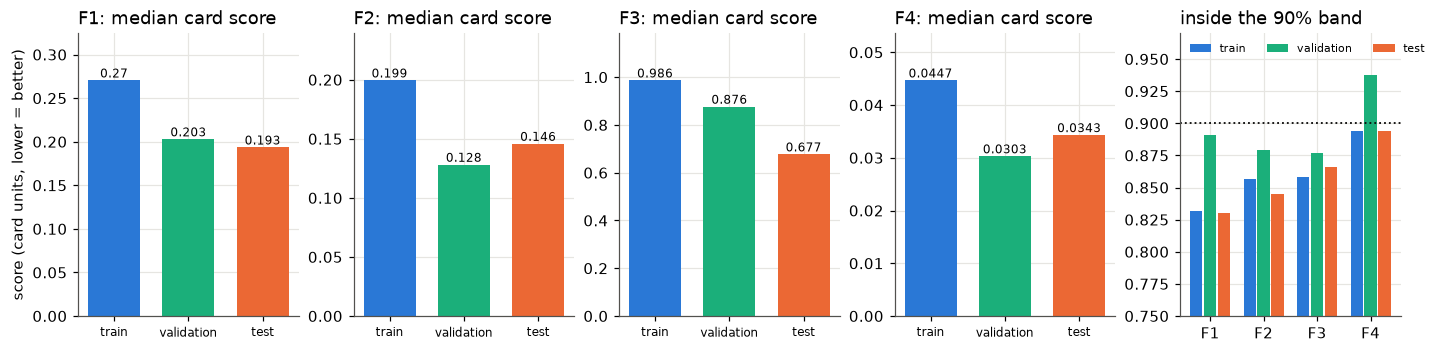

In [6]:
fams = sorted(FAM)
fig, axes = plt.subplots(1, 5, figsize=(13, 3.1), layout="constrained")
for ax, f in zip(axes[:4], fams):
    med = [summ.loc[(f, b), "score_median"] for b in BLOCKS]
    ax.bar(range(3), med, color=[BLOCK[b] for b in BLOCKS], width=0.7)
    for i, v in enumerate(med): ax.text(i, v, f"{v:.3g}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(3), BLOCKS, fontsize=8); ax.set_title(f"{f[3:]}: median card score"); ax.set_ylim(0, max(med) * 1.2)
x = np.arange(len(fams)); wb = 0.26
for j, b in enumerate(BLOCKS):
    axes[4].bar(x + (j - 1) * wb, [summ.loc[(f, b), "inside_90"] for f in fams], width=wb - 0.03, color=BLOCK[b], label=b)
axes[4].axhline(0.9, color=INK, ls=":", lw=1.2); axes[4].set_ylim(0.75, 0.97)
axes[4].set_xticks(x, [f[3:] for f in fams]); axes[4].set_title("inside the 90% band"); axes[4].legend(fontsize=7, ncols=3, loc="upper left")
axes[0].set_ylabel("score (card units, lower = better)"); plt.show()

## 4 — Every card

One row per card: its setting, target type, and for each block the number of dates, the mean score and its
three parts, and the share of answers inside the 50 % and 90 % bands.

In [7]:
wide = card_mean[["dates", *COLS]].rename(columns={"composite": "score", "cov50": "inside_50", "cov90": "inside_90"})
report = wide.unstack("block").swaplevel(axis=1)
report = report[[(b, c) for b in BLOCKS for c in wide.columns]]
report.insert(0, ("", "setting"), [chosen[u] for u in report.index.get_level_values("unit")])
report.insert(1, ("", "target"), [CARDS[u]["targets"]["target_type"] for u in report.index.get_level_values("unit")])
fmt = {c: ("{:,.0f}" if c[1] == "dates" else "{:.3f}" if c[1] in ("inside_50", "inside_90") else "{:.4g}")
       for c in report.columns if c[1] not in ("setting", "target")}
report.style.format(fmt).background_gradient(subset=[(b, "inside_90") for b in BLOCKS], cmap="RdYlGn", vmin=0.75, vmax=0.95)

**Test score of every card**, by category (log scale: the cards' units differ by a factor of thousands).

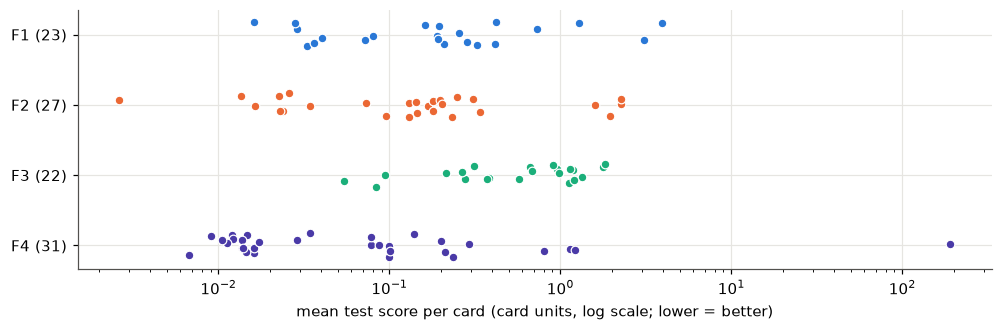

In [8]:
te = cm[cm.block == "test"]
fig, ax = plt.subplots(figsize=(9, 2.9), layout="constrained")
for i, f in enumerate(fams):
    v = te.loc[te.family == f, "composite"]
    ax.scatter(v, i + np.random.default_rng(i).uniform(-0.18, 0.18, len(v)), s=32, color=FAM[f], edgecolor="white", lw=0.8)
ax.set_xscale("log"); ax.set_yticks(range(len(fams)), [f"{f[3:]} ({(te.family == f).sum()})" for f in fams]); ax.invert_yaxis()
ax.set_xlabel("mean test score per card (card units, log scale; lower = better)"); plt.show()

## 5 — Save

`data/report_category.csv` (the §3 table), `data/report_per_unit.csv` (the §4 table) and `data/report_scores.parquet` (every scored date).

In [9]:
category.to_csv(DATA / "report_category.csv")
flat = report.copy(); flat.columns = [f"{a}_{b}" if a else b for a, b in flat.columns]
flat.to_csv(DATA / "report_per_unit.csv")
scores.to_parquet(DATA / "report_scores.parquet", index=False)
for f in ("report_category.csv", "report_per_unit.csv", "report_scores.parquet"):
    print(f"data/{f:<26} {(DATA / f).stat().st_size / 1e6:6.2f} MB")

data/report_category.csv          0.00 MB
data/report_per_unit.csv          0.04 MB
data/report_scores.parquet        2.61 MB


## 6 — How to read it

- **Test** is the number to trust: the model's settings and the way of choosing them never saw those dates.
- **Train** and **validation** were used to choose the settings, so they are a little optimistic.
- A score only compares with another score **on the same card**: a better model on that card has a lower
  score there. Across cards and categories, compare **inside_50** and **inside_90** (targets 0.50 and 0.90).
- Scores also move with the period: a turbulent block (the test dates include 2020 and 2022) scores higher for
  any model than a calm one.